# Ablation study for downscaling using different predictor variable sets using the wind dataset

### Extraction of metic information from multiple trained models (Optional)

The following code is a batchscript which extracts different metric values from the `postprocess_*out.*` files and saves these values in a new file called `results_postprocess.txt`.

```bash
#!/bin/bash

result_file_name="_results_postprocess.txt"
if [ -e "$result_file_name" ]; then
    rm "$result_file_name"
fi

# Search files with the pattern "postprocess_*out.*" and sort them alphabetically
for file in $(ls postprocess_*out.* | sort); do
    # Check if the file contains the required data
    if grep -q "Globally averaged rmse:" "$file" && grep -q "Globally averaged bias:" "$file" && grep -q "Globally averaged grad_amplitude:" "$file" && grep -q "Globally averaged me_std:" "$file"; then
    
        # Find the first 20 lines matching the pattern and extract the part of the line that starts after the substring "INFO:"
        matched_lines=$(grep -m 20 -e "\(Globally averaged \(rmse\|bias\|grad_amplitude\|me_std\):\)\|\(Averaged \\(rmse\|bias\|grad_amplitude\|me_std\) for \(DJF\|JJA\|MAM\|SON\)\)" "$file" | awk -F "INFO: " '{print $2}')

        # Write the filename and the found lines to the result file
        echo "$file" >> $result_file_name
        echo "$matched_lines" >> $result_file_name
        # Add an empty line
        echo >> $result_file_name
    fi
done

```
Then the newly generated `results_postprocess.txt` file needs to replace the original `results_postprocess.txt` file, which is stored in `downscaling_benchmark/postprocess/jupyter_notebooks`.

### Creation of a pandas dataframe containing metric information

The following code creates a pandas dataframe `df` containing the extracted metric information of multiple models using the previosly produced `_results_postprocess.txt` file.

In [13]:
import pandas as pd

def create_dataframe(file_path):
    # Read data from the text file
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize dictionary to store data
    data = {'name': [], 'rmse_global': [], 'rmse_DJF': [], 'rmse_JJA': [], 'rmse_MAM': [], 'rmse_SON': [],
            'bias_global': [], 'bias_DJF': [], 'bias_JJA': [], 'bias_MAM': [], 'bias_SON': [],
            'grad_amplitude_global': [], 'grad_amplitude_DJF': [], 'grad_amplitude_JJA': [], 'grad_amplitude_MAM': [], 'grad_amplitude_SON': [],
            'me_std_global': [], 'me_std_DJF': [], 'me_std_JJA': [], 'me_std_MAM': [], 'me_std_SON': [],}

    # Extract data from the rows
    i = 0
    while i < len(lines):
        for index, (key, value) in enumerate(data.items()):
            if key=='name':
                name = lines[i+index].strip()
                data['name'].append(name)
            else:
                metric_value = float(lines[i+index].split(':')[1].split()[0])
                metric_value_std = float(lines[i+index].split(':')[2].strip())
                data[key].append((metric_value, metric_value_std))
    
        # Update index for the next group of data
        i += 22

    # Create DataFrame
    df = pd.DataFrame(data)

    return df

# Path to the text file
file_path = '_results_postprocess.txt'

# Create DataFrame
df = create_dataframe(file_path)

# Add columns "model" and "predictor_variables"
df['model'] = df['name'].apply(
    lambda x: 'sha_wgan' if 'sha_wgan' in x else
              'deepru' if 'deepru' in x else
              'sha_unet' if 'sha_unet' in x else
              'swinir' if 'swinir' in x else
              'unknown'
)
df['predictor_variables'] = df['name'].apply(lambda x: 'extended' if 'extended' in x else 'normal')

# Remove 'name' column
df_lean = df.drop(columns=['name'])

# Display DataFrame
#print(df_lean)

### Creation of a plot conaining `rmse` and `grad amplitude` of the different models

The following code creates a plot, which contains `rmse` and `grad amplitude` information over the whole year for each model. The datapoints are grouped depending on their model architecture and their used predtictor variables.  
The average of each configuration is calculated and depicted using a bigger symbol.  
The applied model architectures include `sha_unet`, `deepru` and `sha_wgan`.  
The applied predictor variable sets are denoted by `normal` and `extended`.  
These correspond to the following predictor variable sets:  
`normal`: ` ["msl_in", "blh_in", "z_in", "lsm_in", "z_pl500_in", "ws100m_in", "ws_ml137_in", "ws_ml135_in", "ws_ml131_in", "ws_ml127_in", "ws_ml122_in", "ws_ml115_in", "fr_land_tar"]`  
`extended`: `["msl_in", "blh_in", "z_in", "lsm_in", "z_pl700_in", "z_pl500_in", "z_pl850_in", "fr_land_tar", "ws100m_in", "ws_ml131_in", "ws_ml135_in", "ws_ml137_in", "ws_ml115_in", "ws_ml122_in", "ws_ml127_in"]`  
 

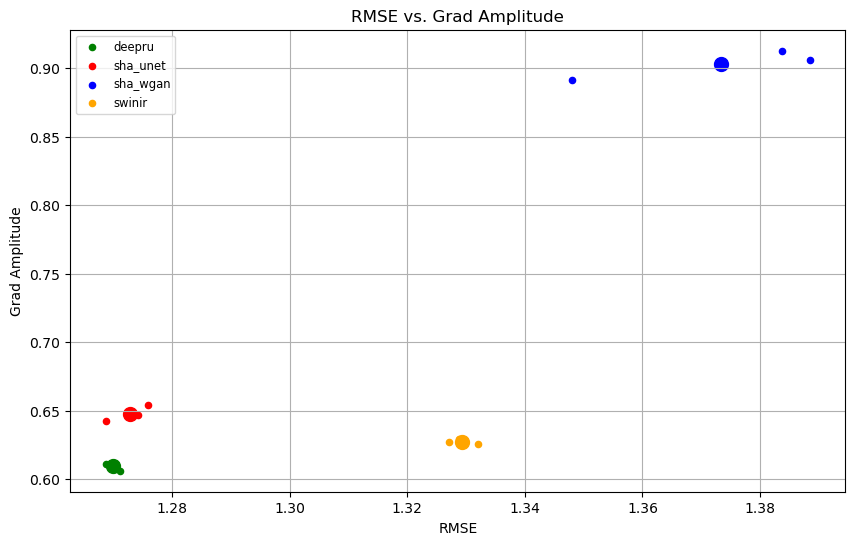

In [17]:
import matplotlib.pyplot as plt

# Function to calculate the average of a tuple
def tuple_mean(tuples):
    return tuple(sum(x) / len(x) for x in zip(*tuples))

# Determine the columns containing tuples
tuple_columns = df_lean.drop(columns=['model', 'predictor_variables']).columns

# Prepare aggregation for each tuple column dynamically
agg_dict = {col: tuple_mean for col in tuple_columns}

# Calculate the average for each model and each predictor variable
avg_df = df_lean.groupby(['model', 'predictor_variables']).agg(agg_dict).reset_index()

# Define colors and markers
colors = {'sha_wgan': 'blue', 'sha_unet': 'red', 'deepru': 'green',  'swinir': 'orange'}
markers = {'normal': 's', 'extended': 'o'}

# Display plot
plt.figure(figsize=(10, 6))

# Plotting data values
for model in df_lean['model'].unique():
    for predictor in df_lean['predictor_variables'].unique():
        if predictor == 'extended':
            temp_df = df_lean[(df_lean['model'] == model) & (df_lean['predictor_variables'] == predictor)]
            plt.scatter(temp_df['rmse_global'].apply(lambda x: x[0]), temp_df['grad_amplitude_global'].apply(lambda x: x[0]), s=20, label=f'{model}',
                        color=colors[model], marker=markers[predictor])

# Plotting average values
for index, row in avg_df.iterrows():
    if row['predictor_variables'] == 'extended':
        plt.scatter(row['rmse_global'][0], row['grad_amplitude_global'][0], 
                s=100,  
                color=colors[row['model']], marker=markers[row['predictor_variables']])


# Adding axis labels and title
plt.xlabel('RMSE')
plt.ylabel('Grad Amplitude')
plt.title('RMSE vs. Grad Amplitude')
plt.legend(fontsize='small')
plt.grid(True)

# Display plot
plt.show()

### Creation of a plot conaining `rmse` and `grad amplitude` of the different models based on season

The following code creates a plot, which contains `rmse` and `grad amplitude` information in each season for each model. The datapoints are grouped depending on their model architecture and their used predtictor variables.  
The average of each configuration is calculated and depicted using a bigger symbol.  
The applied model architectures include `sha_unet`, `deepru` and `sha_wgan`.  
The applied predictor variable sets are denoted by `normal` and `extended`.  

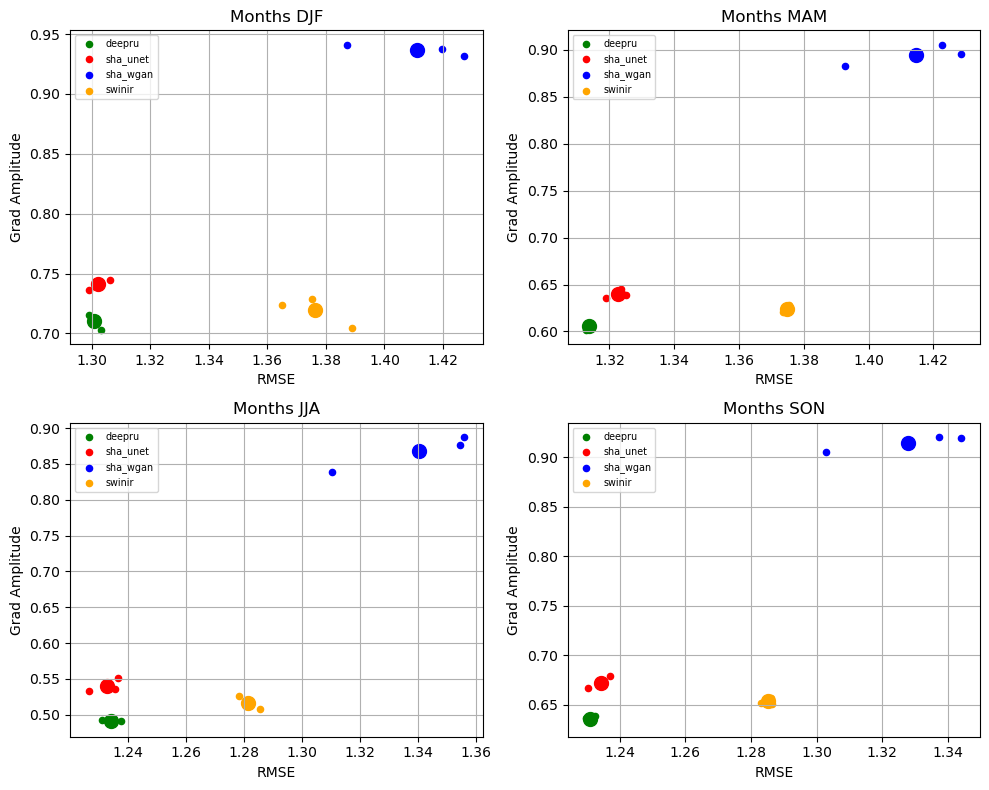

In [19]:
import matplotlib.pyplot as plt

# Function to calculate the average of a tuple
def tuple_mean(tuples):
    return tuple(sum(x) / len(x) for x in zip(*tuples))

# Determine the columns containing tuples
tuple_columns = df_lean.drop(columns=['model', 'predictor_variables']).columns

# Prepare aggregation for each tuple column dynamically
agg_dict = {col: tuple_mean for col in tuple_columns}

# Calculate the average for each model and each predictor variable
avg_df = df_lean.groupby(['model', 'predictor_variables']).agg(agg_dict).reset_index()

# Define colors and markers
colors = {'sha_wgan': 'blue', 'sha_unet': 'red', 'deepru': 'green',  'swinir': 'orange'}
markers = {'normal': 's', 'extended': 'o'}

# Create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plotting data values and average values on the first plot
axs[0, 0].set_title('Months DJF')
axs[0, 0].set_xlabel('RMSE')
axs[0, 0].set_ylabel('Grad Amplitude')
axs[0, 0].grid(True)

# Plotting data values
for model in df_lean['model'].unique():
    for predictor in df_lean['predictor_variables'].unique():
        if predictor == 'extended':
            temp_df = df_lean[(df_lean['model'] == model) & (df_lean['predictor_variables'] == predictor)]
            axs[0, 0].scatter(temp_df['rmse_DJF'].apply(lambda x: x[0]), temp_df['grad_amplitude_DJF'].apply(lambda x: x[0]), s=20, label=f'{model}',
                        color=colors[model], marker=markers[predictor])

# Plotting average values
for index, row in avg_df.iterrows():
    if row['predictor_variables'] == 'extended':
        axs[0, 0].scatter(row['rmse_DJF'][0], row['grad_amplitude_DJF'][0], 
                s=100,  
                color=colors[row['model']], marker=markers[row['predictor_variables']])

axs[0, 0].legend(fontsize='x-small')

# For the other plots, leave them empty for now
axs[1, 0].set_title('Months JJA')
axs[1, 0].set_xlabel('RMSE')
axs[1, 0].set_ylabel('Grad Amplitude')
axs[1, 0].grid(True)

# Plotting data values
for model in df_lean['model'].unique():
    for predictor in df_lean['predictor_variables'].unique():
        if predictor == 'extended':
            temp_df = df_lean[(df_lean['model'] == model) & (df_lean['predictor_variables'] == predictor)]
            axs[1, 0].scatter(temp_df['rmse_JJA'].apply(lambda x: x[0]), temp_df['grad_amplitude_JJA'].apply(lambda x: x[0]), s=20, label=f'{model}',
                        color=colors[model], marker=markers[predictor])

# Plotting average values
for index, row in avg_df.iterrows():
    if row['predictor_variables'] == 'extended':
        axs[1, 0].scatter(row['rmse_JJA'][0], row['grad_amplitude_JJA'][0], 
                s=100,  
                color=colors[row['model']], marker=markers[row['predictor_variables']])

axs[1, 0].legend(fontsize='x-small')

axs[0, 1].set_title('Months MAM')
axs[0, 1].set_xlabel('RMSE')
axs[0, 1].set_ylabel('Grad Amplitude')
axs[0, 1].grid(True)

# Plotting data values
for model in df_lean['model'].unique():
    for predictor in df_lean['predictor_variables'].unique():
        if predictor == 'extended':
            temp_df = df_lean[(df_lean['model'] == model) & (df_lean['predictor_variables'] == predictor)]
            axs[0, 1].scatter(temp_df['rmse_MAM'].apply(lambda x: x[0]), temp_df['grad_amplitude_MAM'].apply(lambda x: x[0]), s=20, label=f'{model}',
                        color=colors[model], marker=markers[predictor])

# Plotting average values
for index, row in avg_df.iterrows():
    if row['predictor_variables'] == 'extended':
        axs[0, 1].scatter(row['rmse_MAM'][0], row['grad_amplitude_MAM'][0], 
                s=100,  
                color=colors[row['model']], marker=markers[row['predictor_variables']])

axs[0, 1].legend(fontsize='x-small')

axs[1, 1].set_title('Months SON')
axs[1, 1].set_xlabel('RMSE')
axs[1, 1].set_ylabel('Grad Amplitude')
axs[1, 1].grid(True)

# Plotting data values
for model in df_lean['model'].unique():
    for predictor in df_lean['predictor_variables'].unique():
        if predictor == 'extended':
            temp_df = df_lean[(df_lean['model'] == model) & (df_lean['predictor_variables'] == predictor)]
            axs[1, 1].scatter(temp_df['rmse_SON'].apply(lambda x: x[0]), temp_df['grad_amplitude_SON'].apply(lambda x: x[0]), s=20, label=f'{model}',
                        color=colors[model], marker=markers[predictor])

# Plotting average values
for index, row in avg_df.iterrows():
    if row['predictor_variables'] == 'extended':
        axs[1, 1].scatter(row['rmse_SON'][0], row['grad_amplitude_SON'][0], 
                s=100,  
                color=colors[row['model']], marker=markers[row['predictor_variables']])

axs[1, 1].legend(fontsize='x-small')

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()